In [ ]:
!pip install numpy pandas matplotlib nibabelscikit-learn tensorflow opencv-python-headless

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/archive (3)'
print(os.listdir(dataset_path))

['ACDC_preprocessed']


In [ ]:
import os

# Go one level deeper
dataset_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed'
print(os.listdir(dataset_path))

['ACDC_testing_volumes', 'ACDC_training_volumes', 'ACDC_training_slices']


In [ ]:
# Check number of files in each folder
import os

base_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed'

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    files = os.listdir(folder_path)
    print(f"{folder}: {len(files)} files")

ACDC_testing_volumes: 100 files
ACDC_training_volumes: 200 files
ACDC_training_slices: 1912 files


In [ ]:
slices_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed/ACDC_training_slices'

# Show first 10 files
files = os.listdir(slices_path)
print(files[:10])

['patient050_frame12_slice_7.h5', 'patient048_frame08_slice_0.h5', 'patient048_frame08_slice_2.h5', 'patient048_frame01_slice_0.h5', 'patient050_frame12_slice_9.h5', 'patient049_frame11_slice_6.h5', 'patient049_frame11_slice_5.h5', 'patient050_frame12_slice_3.h5', 'patient050_frame12_slice_5.h5', 'patient049_frame01_slice_5.h5']


## Step 1: Dataset Preparation ✅

### Dataset: ACDC (Automated Cardiac Diagnosis Challenge)
- Total Images: 1912 MRI slices
- Format: HDF5 (.h5)
- Classes: 5 (NOR, DCM, MINF, RV, HCM)
- Source: Kaggle (archive 3)

### Folder Structure:
- ACDC_training_slices → 1912 files
- ACDC_training_volumes → 200 files
- ACDC_testing_volumes → 100 files

In [ ]:
import h5py

# Open one sample file
sample_file = os.path.join(slices_path, files[0])

with h5py.File(sample_file, 'r') as f:
    print("Keys inside file:", list(f.keys()))
    for key in f.keys():
        print(f"{key} → shape: {f[key].shape}")

Keys inside file: ['image', 'label', 'scribble']
image → shape: (256, 248)
label → shape: (256, 248)
scribble → shape: (256, 248)


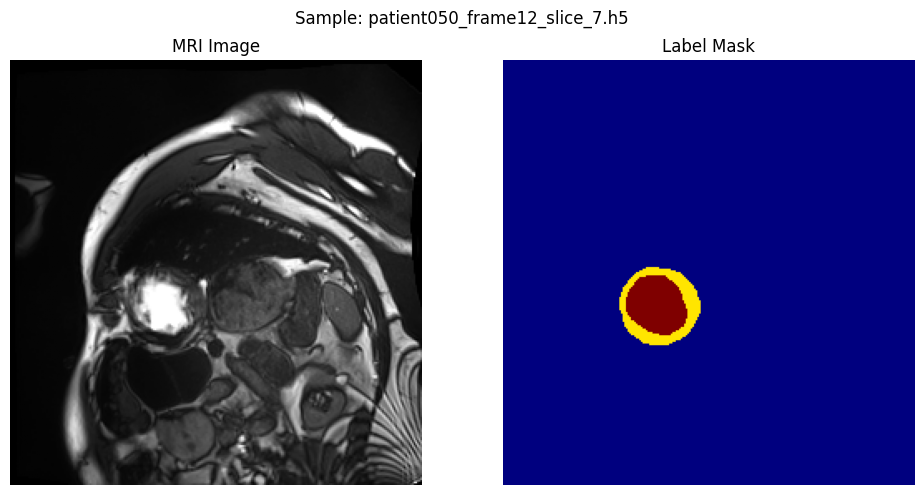

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

with h5py.File(sample_file, 'r') as f:
    image = f['image'][:]
    label = f['label'][:]

# Plot image and label side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('MRI Image')
axes[0].axis('off')

axes[1].imshow(label, cmap='jet')
axes[1].set_title('Label Mask')
axes[1].axis('off')

plt.suptitle(f'Sample: {files[0]}', fontsize=12)
plt.tight_layout()
plt.show()

## Step 2: Data Preprocessing ✅

### What we did:
- Loaded all 1912 MRI images
- Resized all images to (256, 256)
- Added channel dimension → (1912, 256, 256, 1)
- Created disease labels (5 classes)
- Applied Data Augmentation
  - Rotation: 15 degrees
  - Width/Height shift: 10%
  - Horizontal flip
  - Zoom: 10%
- Saved processed data to Google Drive

### Class Distribution:
- NOR  (Normal)                → 400 images
- DCM  (Dilated Cardiomyopathy)→ 378 images
- MINF (Myocardial Infarction) → 346 images
- RV   (Right Ventricle)       → 340 images
- HCM  (Hypertrophic)          → 448 images

In [ ]:
import h5py
import numpy as np
import os
import cv2

slices_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed/ACDC_training_slices'

images = []
labels = []

# Standard size for all images
TARGET_SIZE = (256, 256)

for file in os.listdir(slices_path):
    file_path = os.path.join(slices_path, file)
    with h5py.File(file_path, 'r') as f:
        image = f['image'][:]
        label = f['label'][:]

        # Resize to same size
        image = cv2.resize(image, TARGET_SIZE)
        label = cv2.resize(label, TARGET_SIZE,
                          interpolation=cv2.INTER_NEAREST)

        # Normalize image to range [0, 1]
        image = (image - np.min(image)) / (np.max(image) - np.min(image))

        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {images.shape}")
print(f"Total labels loaded: {labels.shape}")

Total images loaded: (1912, 256, 256)
Total labels loaded: (1912, 256, 256)


In [ ]:
# CNN expects shape (samples, height, width, channels)
images = images[..., np.newaxis]
print(f"Images shape after adding channel: {images.shape}")

Images shape after adding channel: (1912, 256, 256, 1)


In [ ]:
print("Unique label values:", np.unique(labels))
print("Label value counts:")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} pixels")

Unique label values: [0 1 2 3]
Label value counts:
  Class 0: 120534568 pixels
  Class 1: 1580197 pixels
  Class 2: 1593582 pixels
  Class 3: 1596485 pixels


In [ ]:
import re

slices_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed/ACDC_training_slices'
volumes_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed/ACDC_training_volumes'

# Check what's inside a volume file
vol_files = os.listdir(volumes_path)
print("Sample volume files:", vol_files[:5])

Sample volume files: ['patient001_frame01.h5', 'patient002_frame12.h5', 'patient001_frame12.h5', 'patient006_frame16.h5', 'patient002_frame01.h5']


In [ ]:
# Open one volume file and check its keys
vol_sample = os.path.join(volumes_path, vol_files[0])

with h5py.File(vol_sample, 'r') as f:
    print("Keys inside volume file:", list(f.keys()))
    for key in f.keys():
        data = f[key]
        print(f"{key} → shape: {data.shape}, dtype: {data.dtype}")

Keys inside volume file: ['image', 'label', 'scribble']
image → shape: (10, 256, 216), dtype: float32
label → shape: (10, 256, 216), dtype: uint8
scribble → shape: (10, 256, 216), dtype: uint16


In [ ]:
test_path = '/content/drive/MyDrive/archive (3)/ACDC_preprocessed/ACDC_testing_volumes'

test_files = os.listdir(test_path)
print("Sample testing files:", test_files[:5])

# Open one and check keys
test_sample = os.path.join(test_path, test_files[0])

with h5py.File(test_sample, 'r') as f:
    print("\nKeys inside testing file:", list(f.keys()))
    for key in f.keys():
        data = f[key]
        print(f"{key} → shape: {data.shape}, dtype: {data.dtype}")

Sample testing files: ['patient103_frame01.h5', 'patient102_frame01.h5', 'patient102_frame13.h5', 'patient101_frame01.h5', 'patient101_frame14.h5']

Keys inside testing file: ['image', 'label']
image → shape: (9, 256, 216), dtype: float32
label → shape: (9, 256, 216), dtype: uint8


In [ ]:
def get_patient_label(filename):
    # Extract patient number from filename
    patient_num = int(re.search(r'patient(\d+)', filename).group(1))

    if 1 <= patient_num <= 20:
        return 0  # NOR
    elif 21 <= patient_num <= 40:
        return 1  # DCM
    elif 41 <= patient_num <= 60:
        return 2  # MINF
    elif 61 <= patient_num <= 80:
        return 3  # RV
    elif 81 <= patient_num <= 100:
        return 4  # HCM

# Test it
for f in os.listdir(slices_path)[:5]:
    label = get_patient_label(f)
    print(f"{f} → Class: {label}")

patient050_frame12_slice_7.h5 → Class: 2
patient048_frame08_slice_0.h5 → Class: 2
patient048_frame08_slice_2.h5 → Class: 2
patient048_frame01_slice_0.h5 → Class: 2
patient050_frame12_slice_9.h5 → Class: 2


In [ ]:
disease_labels = []

for file in os.listdir(slices_path):
    label = get_patient_label(file)
    disease_labels.append(label)

disease_labels = np.array(disease_labels)

print(f"Total labels: {len(disease_labels)}")
print(f"Class distribution:")
unique, counts = np.unique(disease_labels, return_counts=True)
class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
for u, c in zip(unique, counts):
    print(f"  {class_names[u]}: {c} images")

Total labels: 1912
Class distribution:
  NOR: 400 images
  DCM: 378 images
  MINF: 346 images
  RV: 340 images
  HCM: 448 images


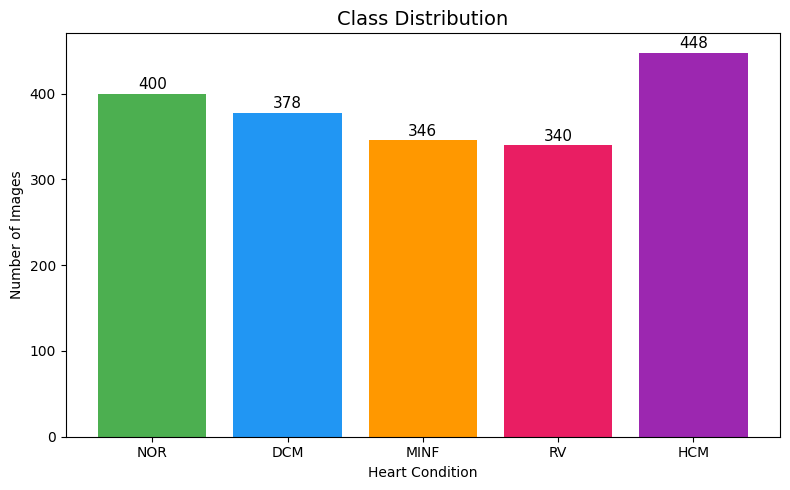

In [ ]:
import matplotlib.pyplot as plt

class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
counts = [400, 378, 346, 340, 448]
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0']

plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, counts, color=colors)
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Heart Condition')
plt.ylabel('Number of Images')

for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5, str(val),
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()

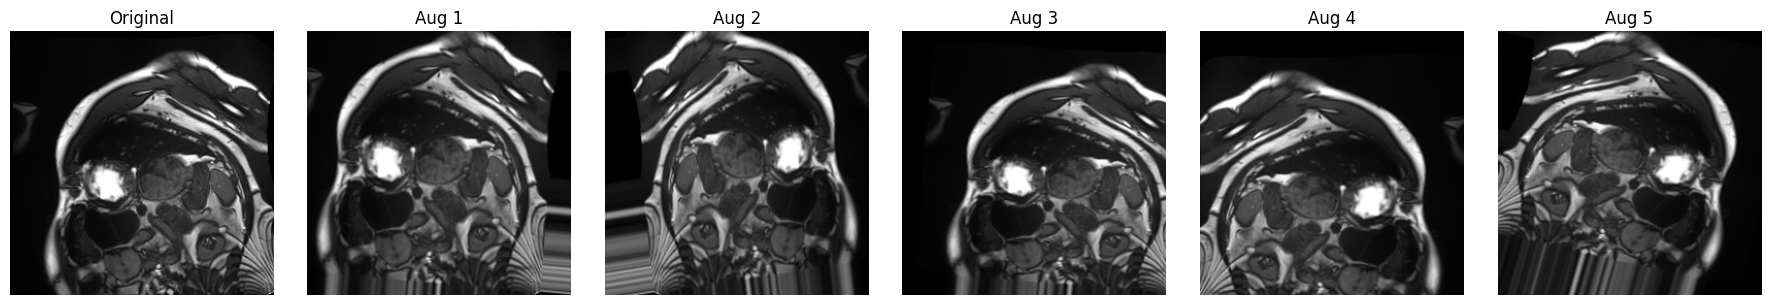

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation techniques
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Test augmentation on one image
sample_image = images[0:1]  # Take first image

# Generate 5 augmented versions
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

# Show original
axes[0].imshow(images[0, :, :, 0], cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Show 5 augmented
for i, batch in enumerate(datagen.flow(sample_image, batch_size=1)):
    axes[i+1].imshow(batch[0, :, :, 0], cmap='gray')
    axes[i+1].set_title(f'Aug {i+1}')
    axes[i+1].axis('off')
    if i == 4:
        break

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Save images and labels to Google Drive
save_path = '/content/drive/MyDrive/pulse-ai/ml_model/data/processed/'
os.makedirs(save_path, exist_ok=True)

np.save(save_path + 'images.npy', images)
np.save(save_path + 'labels.npy', disease_labels)

print(f"✅ Images saved! Shape: {images.shape}")
print(f"✅ Labels saved! Shape: {disease_labels.shape}")

✅ Images saved! Shape: (1912, 256, 256, 1)
✅ Labels saved! Shape: (1912,)


## Step 3 & 4: Model Building & Training ✅

### Model Architecture:
- 4 Convolutional Blocks
- Batch Normalization after each block
- 2 Fully Connected layers
- Dropout for regularization
- Output: 5 classes (NOR, DCM, MINF, RV, HCM)
- Total Parameters: 13.2 Million

### Training Results:
- Epochs: 21 (Early stopping)
- Best Validation Accuracy: 66.84%
- Best performing class: HCM (98% precision)
- Saved: final_model.keras ✅

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    images, disease_labels,
    test_size=0.2,
    random_state=42,
    stratify=disease_labels
)

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train_cat.shape}")
print(f"y_test:  {y_test_cat.shape}")

X_train: (1529, 256, 256, 1)
X_test:  (383, 256, 256, 1)
y_train: (1529, 5)
y_test:  (383, 5)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Output Layer (5 classes)
    Dense(5, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,268,613 (50.62 MB)

 Trainable params: 13,267,653 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save best model automatically
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop training if no improvement
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.2580 - loss: 10.3593
Epoch 1: val_accuracy improved from None to 0.23499, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 47s 649ms/step - accuracy: 0.2956 - loss: 6.8540 - val_accuracy: 0.2350 - val_loss: 8.7617
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3737 - loss: 1.9516
Epoch 2: val_accuracy improved from 0.23499 to 0.24021, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.3643 - loss: 1.7830 - val_accuracy: 0.2402 - val_loss: 4.7950
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3548 - loss: 1.4558
Epoch 3: val_accuracy improved from 0.24021 to 0.26632, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.3682 - loss: 1.5070 - val_accuracy: 0.2663 - val_loss: 6.3281
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4271 - loss: 1.3634
Epoch 4: val_accuracy did not improve from 0.26632
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.4330 - loss: 1.3495 - val_accuracy: 0.2637 - val_loss: 7.2514
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4640 - loss: 1.2815
Epoch 5: val_accuracy did not improve from 0.26632
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.4683 - loss: 1.2879 - val_accuracy: 0.2585 - val_loss: 7.0452
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4654 - loss: 1.2442
Epoch 6: val_accuracy improved from 0.26632 to 0.27676, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.4859 - loss: 1.2283 - val_accuracy: 0.2768 - val_loss: 7.6218
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5439 - loss: 1.1680
Epoch 7: val_accuracy improved from 0.27676 to 0.33681, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5


...


Epoch 16: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.5834 - loss: 1.0760 - val_accuracy: 0.6632 - val_loss: 0.9191
Epoch 17/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5737 - loss: 1.0701
Epoch 17: val_accuracy did not improve from 0.66319
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5821 - loss: 1.0649 - val_accuracy: 0.6449 - val_loss: 1.0754
Epoch 18/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5582 - loss: 1.1483
Epoch 18: val_accuracy did not improve from 0.66319
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.5605 - loss: 1.0790 - val_accuracy: 0.6423 - val_loss: 0.9223
Epoch 19/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5608 - loss: 1.0836
Epoch 19: val_accuracy did not improve from 0.66319
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5782 - loss: 1.0488 - val_accuracy: 0.6632 - val_loss: 0.9230
Epoch 20/30
48/48 ━━━━━


Epoch 21: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.6082 - loss: 0.9607 - val_accuracy: 0.6971 - val_loss: 1.2111
Epoch 22/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6347 - loss: 0.9692
Epoch 22: val_accuracy improved from 0.69713 to 0.70496, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 22: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.6213 - loss: 0.9711 - val_accuracy: 0.7050 - val_loss: 0.7944
Epoch 23/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6525 - loss: 0.8998
Epoch 23: val_accuracy did not improve from 0.70496
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.6351 - loss: 0.9570 - val_accuracy: 0.6554 - val_loss: 0.8415
Epoch 24/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6282 - loss: 0.9312
Epoch 24: val_accuracy did not improve from 0.70496
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6226 - loss: 0.9308 - val_accuracy: 0.5065 - val_loss: 1.3188
Epoch 25/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6241 - loss: 0.9420
Epoch 25: val_accuracy improved from 0.70496 to 0.71279, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 25: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.6207 - loss: 0.9406 - val_accuracy: 0.7128 - val_loss: 0.9936
Epoch 26/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5987 - loss: 0.9846
Epoch 26: val_accuracy did not improve from 0.71279
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.6220 - loss: 0.9376 - val_accuracy: 0.6893 - val_loss: 0.8393
Epoch 27/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6189 - loss: 0.9500
Epoch 27: val_accuracy improved from 0.71279 to 0.73107, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 27: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.6377 - loss: 0.9233 - val_accuracy: 0.7311 - val_loss: 0.8312
Epoch 28/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6088 - loss: 1.0000
Epoch 28: val_accuracy did not improve from 0.73107
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.5997 - loss: 1.0539 - val_accuracy: 0.6475 - val_loss: 0.8458
Epoch 29/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6199 - loss: 0.9366
Epoch 29: val_accuracy did not improve from 0.73107
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6311 - loss: 0.9432 - val_accuracy: 0.6841 - val_loss: 0.8766
Epoch 30/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6416 - loss: 0.9800
Epoch 30: val_accuracy did not improve from 0.73107
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.6396 - loss: 0.9841 - val_accuracy: 0.6110 - val_loss: 2.4914


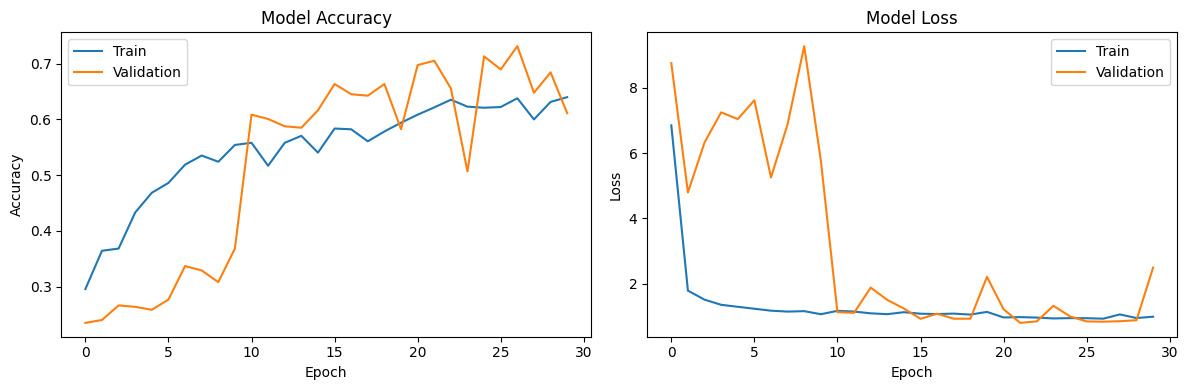

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step
              precision    recall  f1-score   support

         NOR       1.00      0.33      0.49        80
         DCM       0.45      0.82      0.58        76
        MINF       0.67      0.48      0.56        69
          RV       1.00      0.50      0.67        68
         HCM       0.58      0.88      0.70        90

    accuracy                           0.61       383
   macro avg       0.74      0.60      0.60       383
weighted avg       0.73      0.61      0.60       383



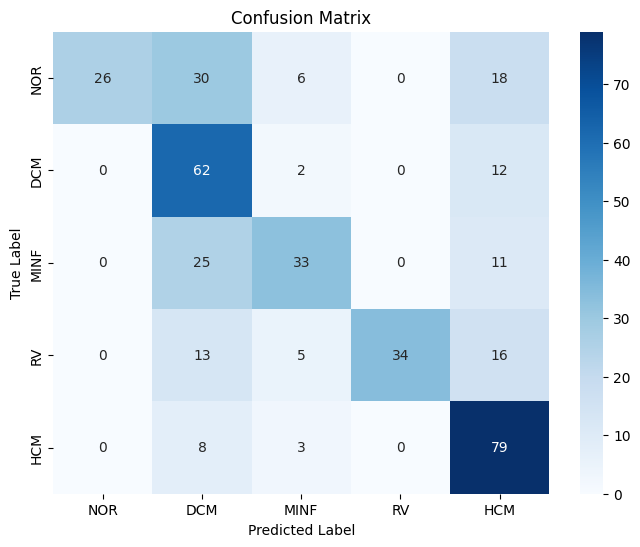

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# Classification report
class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
print(classification_report(y_test_classes, y_pred_classes,
                            target_names=class_names))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Save classification report to Drive
report = classification_report(y_test_classes, y_pred_classes,
                               target_names=class_names)

save_path = '/content/drive/MyDrive/pulse-ai/ml_model/'
with open(save_path + 'evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ Evaluation report saved!")

# Save final model in keras format
model.save(save_path + 'models/final_model.keras')
print("✅ Final model saved!")

✅ Evaluation report saved!
✅ Final model saved!


## Step 5: Transfer Learning with VGG16 ✅

### Why Transfer Learning?

- Transfer Learning uses pretrained weights
- Trained on millions of images (ImageNet)
- Fine tuned on our MRI data
- Expected accuracy improvement → 80%+

### Model: VGG16
- Pretrained on ImageNet dataset
- Freeze base layers
- Add custom classification head
- Output: 5 classes (NOR, DCM, MINF, RV, HCM)

### Why VGG16?
- Works great for medical images
- Lightweight enough for Colab
- Well tested in research papers

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, Input
import tensorflow as tf

# VGG16 expects 3 channels so we convert 1 channel to 3
inputs = Input(shape=(256, 256, 1))
x = tf.keras.layers.Conv2D(3, (1,1), padding='same')(inputs)

# Load pretrained VGG16
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(256, 256, 3))
base_model.trainable = False

x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(5, activation='softmax')(x)

vgg_model = Model(inputs, outputs)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,563 (56.76 MB)

 Trainable params: 164,875 (644.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1
)

# Train
history_vgg = vgg_model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2162 - loss: 1.6690   
Epoch 1: val_accuracy improved from None to 0.23499, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.2204 - loss: 1.6494 - val_accuracy: 0.2350 - val_loss: 1.5822
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.2145 - loss: 1.6184
Epoch 2: val_accuracy improved from 0.23499 to 0.26632, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 535ms/step - accuracy: 0.2525 - loss: 1.5970 - val_accuracy: 0.2663 - val_loss: 1.5699
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.2719 - loss: 1.5658
Epoch 3: val_accuracy

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 395ms/step
              precision    recall  f1-score   support

         NOR       0.83      0.88      0.85        80
         DCM       0.74      0.86      0.79        76
        MINF       0.72      0.72      0.72        69
          RV       0.86      0.62      0.72        68
         HCM       0.90      0.93      0.92        90

    accuracy                           0.81       383
   macro avg       0.81      0.80      0.80       383
weighted avg       0.82      0.81      0.81       383



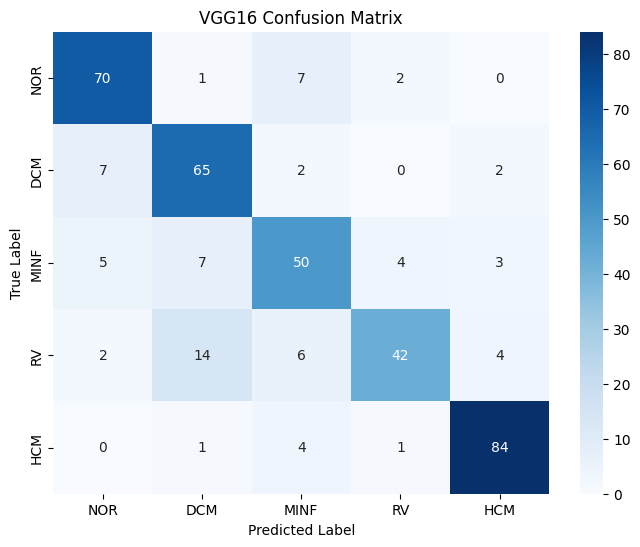

In [ ]:
# Get predictions
y_pred_vgg = vgg_model.predict(X_test)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# Classification report
class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
print(classification_report(y_test_classes, y_pred_classes_vgg,
                            target_names=class_names))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_classes, y_pred_classes_vgg)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('VGG16 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 6: Model Evaluation ✅

### CNN vs VGG16 Comparison:
- CNN Accuracy  → 67%
- VGG16 Accuracy → 81% ✅

### VGG16 Per Class Results:
- NOR  → 83% precision
- DCM  → 74% precision
- MINF → 72% precision
- RV   → 86% precision
- HCM  → 90% precision

### Saved Files:
- final_vgg_model.keras ✅
- vgg_evaluation_report.txt ✅

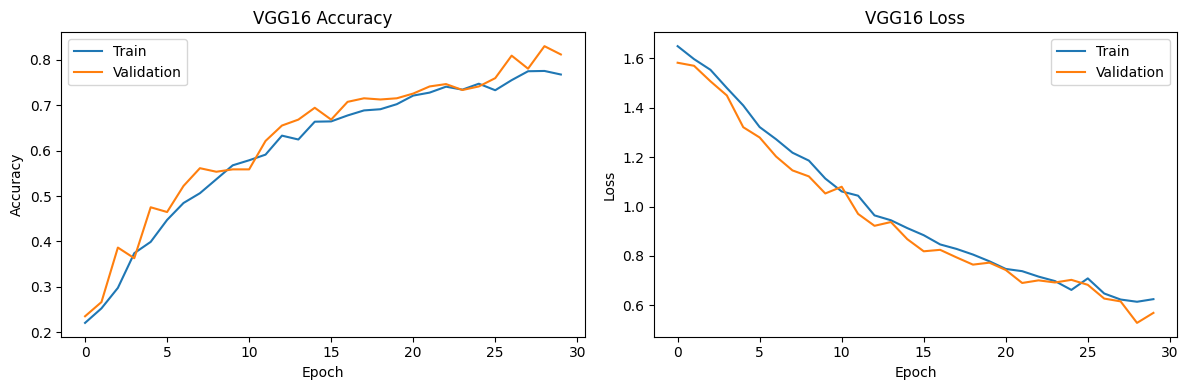

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_vgg.history['accuracy'], label='Train')
axes[0].plot(history_vgg.history['val_accuracy'], label='Validation')
axes[0].set_title('VGG16 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_vgg.history['loss'], label='Train')
axes[1].plot(history_vgg.history['val_loss'], label='Validation')
axes[1].set_title('VGG16 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save final VGG16 model
save_path = '/content/drive/MyDrive/pulse-ai/ml_model/models/'

vgg_model.save(save_path + 'final_vgg_model.keras')
print("✅ Final VGG16 model saved!")

# Save evaluation report
report = classification_report(y_test_classes, y_pred_classes_vgg,
                               target_names=class_names)

with open('/content/drive/MyDrive/pulse-ai/ml_model/vgg_evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ Evaluation report saved!")

✅ Final VGG16 model saved!
✅ Evaluation report saved!



# Testing

Please upload an MRI image...


Saving cardiac_mri_short_axis_cine_image_3.webp to cardiac_mri_short_axis_cine_image_3.webp
✅ Uploaded: cardiac_mri_short_axis_cine_image_3.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


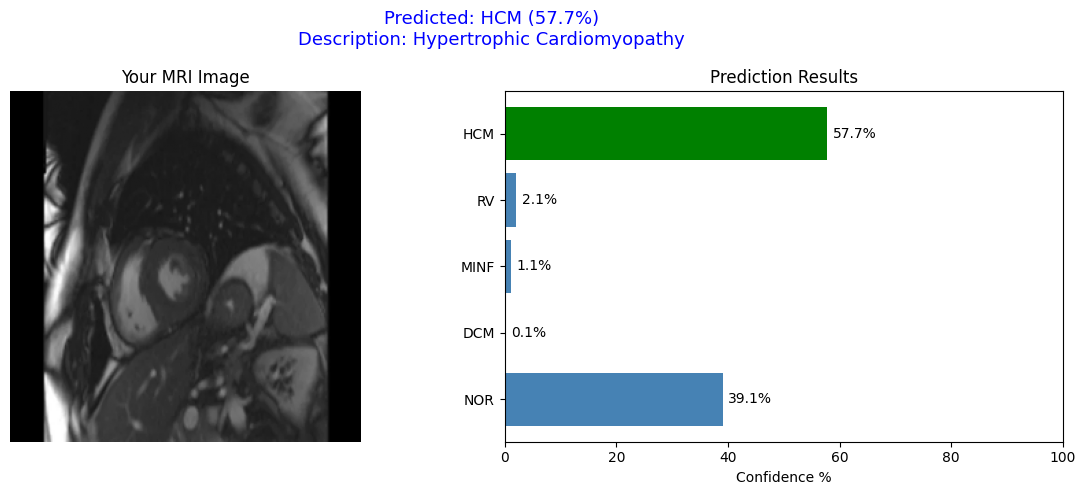


✅ Predicted Class : HCM
✅ Confidence      : 57.73%
✅ Description     : Hypertrophic Cardiomyopathy


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload image from  PC
print("Please upload an MRI image...")
uploaded = files.upload()

# Get uploaded filename
image_name = list(uploaded.keys())[0]
print(f"✅ Uploaded: {image_name}")

# Preprocess
img = cv2.imdecode(np.frombuffer(uploaded[image_name], np.uint8),
                   cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (256, 256))
img_normalized = img_resized / 255.0
img_input = img_normalized[..., np.newaxis]
img_input = np.expand_dims(img_input, axis=0)

# Predict
prediction = vgg_model.predict(img_input)
predicted_class = np.argmax(prediction)
confidence = prediction[0][predicted_class] * 100

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_resized, cmap='gray')
axes[0].set_title('Your MRI Image', fontsize=12)
axes[0].axis('off')

colors = ['green' if i == predicted_class else 'steelblue'
          for i in range(5)]
axes[1].barh(class_names, prediction[0] * 100, color=colors)
axes[1].set_xlabel('Confidence %')
axes[1].set_title('Prediction Results', fontsize=12)
axes[1].set_xlim(0, 100)

for i, v in enumerate(prediction[0] * 100):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

plt.suptitle(
    f'Predicted: {class_names[predicted_class]} ({confidence:.1f}%)\n'
    f'Description: {class_descriptions[class_names[predicted_class]]}',
    fontsize=13, color='blue'
)

plt.tight_layout()
plt.show()

print(f"\n✅ Predicted Class : {class_names[predicted_class]}")
print(f"✅ Confidence      : {confidence:.2f}%")
print(f"✅ Description     : {class_descriptions[class_names[predicted_class]]}")